# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import time
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [18]:
corpus = '''
Once upon a time, in a small village surrounded by green hills, there lived a young boy named Arjun. He loved exploring the forests near his home and dreamed of discovering hidden treasures. Every morning, he would pack a small bag and set out on a new adventure.

One sunny afternoon, Arjun noticed a narrow path he had never seen before. Curious, he followed it deep into the woods. The trees grew taller, and the sounds of birds echoed through the forest. After walking for hours, he found an ancient stone arch covered with vines.

As he stepped through the arch, he entered a beautiful valley filled with colorful flowers. In the center stood a crystal-clear lake that sparkled under the sunlight. Arjun felt as if he had entered another world. He carefully walked toward the lake and noticed something shining beneath the water.

The shining object turned out to be a golden key. Excited by his discovery, Arjun searched the valley for a lock that might match it. Near the edge of the lake, he found an old wooden chest hidden among the bushes.

With trembling hands, he inserted the key into the lock. The chest opened slowly, revealing ancient books, maps, and letters from travelers who had visited the valley centuries ago. Arjun realized that the true treasure was not gold but the knowledge contained in those pages.

For many weeks, Arjun returned to the valley to read the books and study the maps. He learned about distant lands, forgotten civilizations, and incredible inventions. The more he learned, the more he understood the value of curiosity and education.

Years later, Arjun became a famous explorer and writer. He shared the stories and knowledge he had discovered with people around the world. Whenever someone asked about the secret of his success, he smiled and said that every great journey begins with a single step into the unknown.

The valley remained a special place in his heart. Though he traveled across oceans and mountains, he never forgot the day he followed an unfamiliar path and found a treasure greater than he had ever imagined. His story inspired generations to seek knowledge, embrace adventure, and never stop learning.
'''
print(corpus)


Once upon a time, in a small village surrounded by green hills, there lived a young boy named Arjun. He loved exploring the forests near his home and dreamed of discovering hidden treasures. Every morning, he would pack a small bag and set out on a new adventure.

One sunny afternoon, Arjun noticed a narrow path he had never seen before. Curious, he followed it deep into the woods. The trees grew taller, and the sounds of birds echoed through the forest. After walking for hours, he found an ancient stone arch covered with vines.

As he stepped through the arch, he entered a beautiful valley filled with colorful flowers. In the center stood a crystal-clear lake that sparkled under the sunlight. Arjun felt as if he had entered another world. He carefully walked toward the lake and noticed something shining beneath the water.

The shining object turned out to be a golden key. Excited by his discovery, Arjun searched the valley for a lock that might match it. Near the edge of the lake, he

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [19]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 215
X shape: (360, 49)
y shape: (360,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [28]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

t0 = time.time()
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
rnn_train_time = time.time() - t0
print("Vanilla RNN training completed in", round(rnn_train_time, 1), "sec")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed in 28.7 sec


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [30]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

t0 = time.time()
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
lstm_train_time = time.time() - t0
print("LSTM training completed in ",round(lstm_train_time,1),"sec")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM training completed in  34.5 sec


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [31]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

t0 = time.time()
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
gru_train_time = time.time() - t0
print("GRU training completed in ",round(gru_train_time,1),"sec")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU training completed in  28.3 sec


## 📉 Compare Training Loss

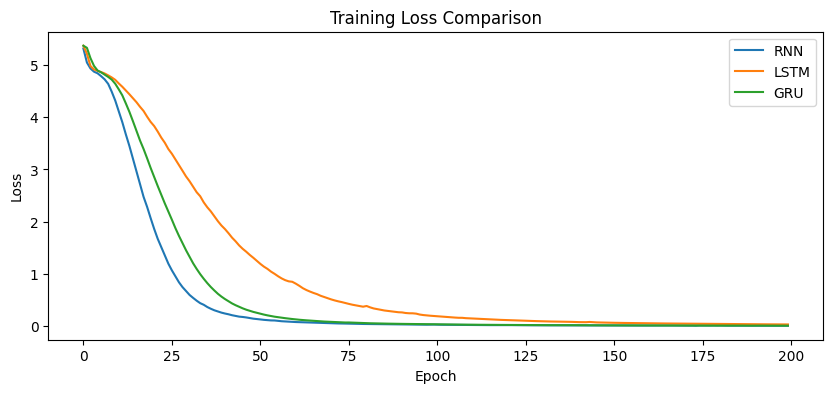

In [24]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [25]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [26]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning he stepped through the arch he entered a beautiful valley
LSTM: deep learning he inserted the key into the lock the chest opened
GRU : deep learning arjun became a famous explorer and writer he shared the


# Memory Handling :-
* Parameter count
* Training time

In [32]:
models = {
    "RNN": (rnn_model, rnn_train_time),
    "LSTM": (lstm_model, lstm_train_time),
    "GRU": (gru_model, gru_train_time),
}

print(f"{'Model':<8}{'Params':>12}{'Train time (s)':>18}")
for name, (model, t) in models.items():
    print(f"{name:<8}{model.count_params():>12,}{t:>18.1f}")

Model         Params    Train time (s)
RNN           66,199              28.7
LSTM         140,311              34.5
GRU          115,991              28.3


# Long-term dependency learning

In [33]:
long_seed = "lstm helps remember long term dependencies and because of this it"

print("Seed:", long_seed)
print()
print("RNN :", generate_text(rnn_model, long_seed, 6))
print("LSTM:", generate_text(lstm_model, long_seed, 6))
print("GRU :", generate_text(gru_model, long_seed, 6))

Seed: lstm helps remember long term dependencies and because of this it

RNN : lstm helps remember long term dependencies and because of this it sunny afternoon arjun noticed a narrow
LSTM: lstm helps remember long term dependencies and because of this it became a famous explorer and writer
GRU : lstm helps remember long term dependencies and because of this it a famous explorer and writer he


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**